# Semantic Entropy Probes Training

Coding linear probes is easy - run logistic regression on saved hidden states from SE generations, and predict binarized SE labels and model correctness. We will replicate our experimental results in this notebook, and we share our example runs for Llama-2-7B short-form generations at [this project](https://wandb.ai/jiatongg/public_semantic_uncertainty) if you want a quick start. We keep some of our visualizations (for Llama2-7b, short-form generations, {NQ Open, TriviaQA, SQuAD, BioASQ}) for quick references.

For clarity, there are some variable naming conventions in this notebooks: `a` means accuracy, `b` means binarized entropy, `s` means SLT token, `t` means TBG token, `i` means In-Distribution (ID), `o` means Out-Of-Distribution (OOD).


This notebook is arranged in sections:
1) [Imports and Downloads](#Imports-and-Downloads) helps you load `wandb` runs into local storage;
2) [Data Preparation](#Data-Preparation) section prepares the training data, encapsulates the training and evaluation codes, and contains some visualization tools;
3) [Probing Acc/SE from Hidden States (id)](#Probing-Acc/SE-from-Hidden-States) section binarizes SE and carries out actual training of SEPs and Acc. Pr. in the In-Distribution setting, where we train and test on the same dataset yet on different splits;
4) [Test probes trained with one dataset on others](#Test-probes-trained-with-one-dataset-on-others) section tests SEPs and Acc. Pr. performances in predicting model correctness on other datasets;
5) The rest sections ([5](#Baselines-and-Performance-Plots), [6](#Save-trained-probes-for-inference)) are for performance comparisons with baselines and model saving.

## Imports and Downloads

In [1]:
%load_ext autoreload
%autoreload 2

import json
import os
import pickle
import shutil
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import scipy
import torch
import wandb
from matplotlib import pyplot as plt
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score, mean_squared_error
from sklearn.model_selection import train_test_split
from pathlib import Path

warnings.filterwarnings("ignore")
plt.rcParams.update({'font.size': 12})
rng = np.random.default_rng(42)
run_files = {
    'UNC_MEA': 'uncertainty_measures.pkl', 
    'VAL_GEN': 'validation_generations.pkl', # essential for SEP training
    'WAN_SUM': 'wandb-summary.json'
} 

In [2]:
model_name = 'Llama2-7b' # replace with your model name
ds_names = ['trivia-qa'] # replace with your actual dataset names (corresponding to run ids)



In [ ]:
# not needed
model_name = 'Llama2-7b' # replace with your model name
#wandb_run_ids = ['ayakayal/semantic_uncertainty/tj5c1ok8']
#wandb_run_ids = ['ayakayal/semantic_uncertainty/talgtdnm']
#wandb_run_ids = ['ayakayal/semantic_uncertainty/pt2esapp']
wandb_run_ids = ['ayakayal/semantic_uncertainty/17tbov5p']


ds_names = ['trivia-qa'] # replace with your actual dataset names (corresponding to run ids)

#notebook_path = '~/semantic-entropy-probes/semantic_entropy_probes' # replace with your notebook path
notebook_path = '/data/projects/mtk53658/semantic-entropy-probes'
project_dir = Path(notebook_path).expanduser()
if (project_dir / "semantic_entropy_probes").exists():
    data_root = project_dir / "semantic_entropy_probes"
else:
    data_root = project_dir
print(data_root)

/data/projects/mtk53658/semantic-entropy-probes


In [ ]:
#not needed
# ensure you are logged in before downloads
!wandb login

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit: 

Aborted!
Aborted!
^C


In [ ]:
#not needed
# Download from wandb
paths_to_save_runs = [
    str(data_root / "wandb_runs" / model_name / f"run-{run_id.split('/')[-1]}")
    for run_id in wandb_run_ids
]
api = wandb.Api()
for local_dir, run_id in zip(paths_to_save_runs, wandb_run_ids):
    local_dir = Path(local_dir).expanduser()
    local_dir.mkdir(parents=True, exist_ok=True)

    run = api.run(run_id)
    run_file_list = list(run.files())
    files_by_basename = {}
    for wb_file in run_file_list:
        files_by_basename.setdefault(Path(wb_file.name).name, []).append(wb_file)

    print(f"\nRun: {run_id}")
    print(f"Saving to: {local_dir}")

    missing = []
    for wanted in run_files.values():
        candidates = files_by_basename.get(wanted, [])
        if not candidates:
            missing.append(wanted)
            continue

        # Prefer the shortest W&B path if duplicates exist.
        wb_file = sorted(candidates, key=lambda f: len(f.name))[0]
        downloaded = wb_file.download(root=str(local_dir), replace=True, exist_ok=True)

        target = local_dir / wanted
        downloaded_path = Path(downloaded.name)
        if downloaded_path.resolve() != target.resolve():
            shutil.copy2(downloaded_path, target)

        print(f"Downloaded {wanted} from W&B file {wb_file.name} -> {target}")

    if missing:
        raise FileNotFoundError(
            f"Run {run_id} is missing required files: {missing}. "
            f"Available basenames include: {sorted(files_by_basename)[:30]}"
        )

ds_paths = paths_to_save_runs

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/mtk53658/.netrc.



Run: ayakayal/semantic_uncertainty/pt2esapp
Saving to: /data/mtk53658/semantic-entropy-probes/semantic_entropy_probes/wandb_runs/Llama2-7b/run-pt2esapp
Downloaded uncertainty_measures.pkl from W&B file mtk53658/uncertainty/wandb/run-20260629_185838-pt2esapp/files/uncertainty_measures.pkl -> /data/mtk53658/semantic-entropy-probes/semantic_entropy_probes/wandb_runs/Llama2-7b/run-pt2esapp/uncertainty_measures.pkl
Downloaded validation_generations.pkl from W&B file mtk53658/uncertainty/wandb/run-20260629_185838-pt2esapp/files/validation_generations.pkl -> /data/mtk53658/semantic-entropy-probes/semantic_entropy_probes/wandb_runs/Llama2-7b/run-pt2esapp/validation_generations.pkl
Downloaded wandb-summary.json from W&B file wandb-summary.json -> /data/mtk53658/semantic-entropy-probes/semantic_entropy_probes/wandb_runs/Llama2-7b/run-pt2esapp/wandb-summary.json


In [ ]:
#not needed
# Paths need to contain 'validation_generations.pkl' and 'uncertainty_measures.pkl'
# Download from wandb
paths_to_save_runs = [
    str(data_root / "wandb_runs" / model_name / f"run-{run_id.split('/')[-1]}")
    for run_id in wandb_run_ids
]
api = wandb.Api()
ds_paths = paths_to_save_runs
print(ds_paths)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/mtk53658/.netrc.


['/data/projects/mtk53658/semantic-entropy-probes/semantic_entropy_probes/wandb_runs/Llama2-7b/run-17tbov5p']


In [3]:
from pathlib import Path
#ds_paths = [ Path("/build_bak/UQ/UQ/semantic_uncertainty/gpu_mtk53658/uncertainty/wandb/offline-run-20260707_015132-lxwcs9bw/files")]

ds_paths = [ Path("/build_bak/UQ/UQ/semantic_uncertainty/gpu_mtk53658/uncertainty/wandb/offline-run-20260708_203145-mlyabbjz/files")]


In [27]:
for p in ds_paths:
    print(repr(p))

PosixPath('/build_bak/UQ/UQ/semantic_uncertainty/gpu_mtk53658/uncertainty/wandb/offline-run-20260707_015132-lxwcs9bw/files')


In [4]:
POSITIONS = {
    "TBG": "tbg",
    "First": "0",
    "Second": "1",
    "Third": "2",
    # "Fourth": "3",
    # "Fifth": "4",
    # "Fifth-last": "-5",
    # "Fourth-last": "-4",
    "Third-last": "-3",
    "Second-last": "-2",
    "Last": "-1",
}

## Data Preparation

In [5]:
class Dataset:
    def __init__(self, values):
        self.position_datasets = values[0]
        #self.tbg_dataset = values[0]
        #self.slt_dataset = values[1]
        self.entropy = values[1]
        self.accuracies = values[2]
def load_dataset(path, n_sample=2000, use_residual=False):
    path = Path(path).expanduser()
    required = [run_files['VAL_GEN'], run_files['UNC_MEA']]
    missing = [name for name in required if not (path / name).exists()]
    if missing:
        raise FileNotFoundError(f"{path} is missing required files: {missing}")

    # Read validation generated embeddings
    with open(path / run_files['VAL_GEN'], 'rb') as f:
        generations = pickle.load(f)
    
    # Read uncertainty measures (p-true, predictive/semantic uncertainties)
    with open(path / run_files['UNC_MEA'], 'rb') as g:
        measures = pickle.load(g)

    # Attribute names are hardcoded into the files
    entropy = torch.tensor(measures['uncertainty_measures']['cluster_assignment_entropy']).to(torch.float32)
    
    accuracies = torch.tensor([record['most_likely_answer']['accuracy'] for record in generations.values()])
    
    position_datasets = {}

    # for label, position in POSITIONS.items():
    #     position_datasets[label] = torch.stack([
    #         record["most_likely_answer"]["latent_embeddings"][position]
    #         for record in generations.values()
    #     ]).squeeze(2).transpose(0, 1).to(torch.float32)

    for label, position in POSITIONS.items():
        hidden = torch.stack([
            record["most_likely_answer"]["latent_embeddings"][position]
            for record in generations.values()
        ]).squeeze(2).transpose(0, 1).to(torch.float32)
        # hidden shape: (num_layers, n_samples, hidden_dim)

        if use_residual:
            residual = torch.empty_like(hidden)
            residual[0] = hidden[0]          # layer 0 has no predecessor
            residual[1:] = hidden[1:] - hidden[:-1]
            position_datasets[label] = residual
        else:
            position_datasets[label] = hidden
    # tbg_dataset = torch.stack([
    #     record["most_likely_answer"]["latent_embeddings"]["tbg"]
    #     for record in generations.values()
    # ]).squeeze(2).transpose(0, 1).to(torch.float32)

    # slt_dataset = torch.stack([
    #     record["most_likely_answer"]["latent_embeddings"]["-2"]
    #     for record in generations.values()
    # ]).squeeze(2).transpose(0, 1).to(torch.float32)
    

    return (
        {
            label: dataset[:, :n_sample, :]
            for label, dataset in position_datasets.items()
        },
        entropy[:n_sample],
        accuracies[:n_sample],
    )
# def load_dataset(path, n_sample=2000, slt_position='-2', tbg_position='tbg'):
#     path = Path(path).expanduser()

#     with open(path / run_files['VAL_GEN'], 'rb') as f:
#         generations = pickle.load(f)

#     with open(path / run_files['UNC_MEA'], 'rb') as g:
#         measures = pickle.load(g)

#     entropy = torch.tensor(
#         measures['uncertainty_measures']['cluster_assignment_entropy']
#     ).to(torch.float32)

#     accuracies = torch.tensor([
#         record['most_likely_answer']['accuracy']
#         for record in generations.values()
#     ])

#     # each latent embedding has shape: [num_layers, 1, hidden_dim]
#     tbg_dataset = torch.stack([
#         record['most_likely_answer']['latent_embeddings'][tbg_position]
#         for record in generations.values()
#     ]).squeeze(2).transpose(0, 1).to(torch.float32)

#     slt_dataset = torch.stack([
#         record['most_likely_answer']['latent_embeddings'][slt_position]
#         for record in generations.values()
#     ]).squeeze(2).transpose(0, 1).to(torch.float32)

#     return (
#         tbg_dataset[:, :n_sample, :],
#         slt_dataset[:, :n_sample, :],
#         entropy[:n_sample],
#         accuracies[:n_sample],
#     )

In [6]:

#  Load all datasets
Ds = []
for path in ds_paths:
    Ds.append(Dataset(load_dataset(path, use_residual=False))) #modify here whether you want residual or not

# Set essential attributes for prettier printing
for i, D in enumerate(Ds):
    D.name = ds_names[i]
    D.path = ds_paths[i]
    # OOD-related
    D.other_ids = [j for j in range(len(Ds)) if j != i]
    D.other_names = [ds_names[j] for j in D.other_ids]

## Probing Acc/SE from Hidden States

### Helper methods

In [7]:
# Create train/val/test splits
def create_Xs_and_ys(datasets, scores, val_test_splits=[0.2, 0.1], test_only=False, no_val=False):
    # Data splitting for sklearn linear models
    X = np.array(datasets)
    y = np.array(scores)

    if test_only:
        X_tests, y_tests = [], []
        
        for i in range(X.shape[0]):
            X_tests.append(X[i])
            y_tests.append(y)
        return (None, None, X_tests, None, None, y_tests)
    
    valid_size = val_test_splits[0]
    test_size = val_test_splits[1]

    X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = [], [], [], [], [], []

    for i in range(X.shape[0]):
        # Split data into train, validation, and test sets
        X_train_val, X_test, y_train_val, y_test = train_test_split(X[i], y, test_size=test_size, random_state=42)
        X_tests.append(X_test)
        y_tests.append(y_test)
        if no_val:
            X_trains.append(X_train_val)
            y_trains.append(y_train_val)
            continue
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=valid_size, random_state=42) 
        X_trains.append(X_train)
        y_trains.append(y_train)
        X_vals.append(X_val)
        y_vals.append(y_val)
    print('X_trains',len(X_trains))
    print(X_trains[0].shape)

    
    print('y_trains',len(y_trains))

    return X_trains, X_vals, X_tests, y_trains, y_vals, y_tests


In [8]:
# Bootstrapping methods from ../semantic_entropy/uncertainty/utils/eval_utils.py
def bootstrap_func(y_true, y_score, func):
    y_tuple = (y_true, y_score)
    
    metric_i = func(*y_tuple)
    metric_dict = {}
    metric_dict['mean'] = metric_i
    metric_dict['bootstrap'] = compatible_bootstrap(
        func, rng)(*y_tuple)  # a bit slow to run

    return metric_dict

def bootstrap(function, rng, n_resamples=1000):
    def inner(data):
        bs = scipy.stats.bootstrap(
            (data, ), function, n_resamples=n_resamples, confidence_level=0.9,
            random_state=rng)
        return {
            'std_err': bs.standard_error,
            'low': bs.confidence_interval.low,
            'high': bs.confidence_interval.high
        }
    return inner

def auroc(y_true, y_score):
    fpr, tpr, thresholds = metrics.roc_curve(y_true, y_score)
    del thresholds
    return metrics.auc(fpr, tpr)

def compatible_bootstrap(func, rng):
    def helper(y_true_y_score):
        # this function is called in the bootstrap
        y_true = np.array([i['y_true'] for i in y_true_y_score])
        y_score = np.array([i['y_score'] for i in y_true_y_score])
        out = func(y_true, y_score)
        return out

    def wrap_inputs(y_true, y_score):
        return [{'y_true': i, 'y_score': j} for i, j in zip(y_true, y_score)]

    def converted_func(y_true, y_score):
        y_true_y_score = wrap_inputs(y_true, y_score)
        return bootstrap(helper, rng=rng)(y_true_y_score)
    return converted_func

In [9]:
# Train and evaluation function.
def sklearn_train_and_evaluate(model, X_train, y_train, X_valid, y_valid, silent=False):
    model.fit(X_train, y_train)
    
    # Calculate training loss and score
    train_probs = model.predict_proba(X_train)
    train_loss = log_loss(y_train, train_probs)

    # Calculate validation loss
    valid_preds = model.predict(X_valid)
    valid_probs = model.predict_proba(X_valid)
    valid_loss = log_loss(y_valid, valid_probs)
    val_accuracy = np.mean((valid_preds == y_valid).astype(int))
    auroc_score = roc_auc_score(y_valid, valid_probs[:,1])
    if not silent:
        print(f"Validation Accuracy: {val_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        print(f"Training Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}")

def sklearn_evaluate_on_test(model, X_test, y_test, silent=False, bootstrap=True):
    test_preds = model.predict(X_test)
    test_probs = model.predict_proba(X_test)
    test_loss = log_loss(y_test, test_probs)
    test_accuracy = np.mean((test_preds == y_test).astype(int))
    
    if bootstrap:
        auroc_score = bootstrap_func(y_test, test_probs[:,1], auroc)
        auroc_score_scalar = auroc_score['mean']
    else:
        auroc_score = auroc_score_scalar = roc_auc_score(y_test, test_probs[:, 1])
    
    if not silent:
        print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score_scalar:.4f}")
    
    return test_loss, test_accuracy, auroc_score

def train_single_metric(D, position_label="TBG", metric="b_entropy"):
    """Train and test one probe for one token position."""

    short_names = {
    "TBG": "tbg",
    "First": "first",
    "Second": "second",
    "Third": "third",
    # "Fourth": "fourth",
    # "Fifth": "fifth",
    # "Fifth-last": "fifth_last",
    # "Fourth-last": "fourth_last",
    "Third-last": "third_last",
    "Second-last": "second_last",
    "Last": "last",
}

    short_name = short_names[position_label]

    X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(
        D.position_datasets[position_label],
        getattr(D, metric)
    )

    accs = []
    aucs = []
    models = []

    for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(
        zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    ):
        print(f"Training on {D.name}-{position_label}-{metric} {i+1}/{len(X_trains)}")

        model = LogisticRegression()
        sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val)
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test)

        accs.append(test_acc)
        aucs.append(test_auc)
        models.append(model)

    setattr(D, f"{short_name}_{metric}_accs", accs)
    setattr(D, f"{short_name}_{metric}_aucs", aucs)
    setattr(D, f"{short_name}_{metric}_models", models)

# simple get-around for unpacking bootstrapping dicts
auc = lambda aucs : [ac['mean'] for ac in aucs] 
idf = lambda x : x  # identical function

In [10]:
# Plotting methods
def plot_metrics_ax(ax, test_metrics_list, model_names, title="", prep_func=auc, 
                    use_logarithm=False, preset_layer_indices=None, legend_outside=False):  # some simple gadgets
    """plot metrics along certain axis in a multi-axis plot (plt.subplots)"""
    if len(test_metrics_list) != len(model_names):
        raise ValueError("The length of test_metrics_list and model_names must be the same.")
    
    for test_metrics, model_name in zip(test_metrics_list, model_names):
        test_metrics = torch.tensor(prep_func(test_metrics), dtype=torch.float32)
        if use_logarithm:
            test_metrics = torch.log(test_metrics + 1e-6)
        if preset_layer_indices is not None:
            layer_indices = preset_layer_indices
        else:
            layer_indices = torch.arange(len(test_metrics)) + 1  # +1 if layer indexing starts at 1
        
        ax.plot(layer_indices, test_metrics, marker='o', linestyle='-', linewidth=2, markersize=5, label=model_name)
    
    ax.set_title(f'{title}', fontsize=14)
    ax.set_xlabel('Layer', fontsize=12)
    ax.set_ylabel(f'Test AUROC scores', fontsize=12)
    
    tick_interval = 5  # Change this value to display more or fewer ticks
    ax.set_xticks(layer_indices[::tick_interval].tolist())
    ax.set_xticklabels(layer_indices[::tick_interval].tolist())
    
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    if legend_outside:
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
    else:
        ax.legend(fontsize=12)

def save_fig(name):
    """save figure with timestamps"""
    full_path = f'{notebook_path}/figures'
    full_path = os.path.expanduser(full_path)
    os.makedirs(full_path, exist_ok=True)
    plt.savefig(f'{full_path}/{name}.pdf', format='pdf', dpi=300)

In [11]:
# Best split for SE binarization.
def best_split(entropy: torch.Tensor, label="Dx"):
    """
    Identify best split for minimizing reconstruction error via low and high SE mean estimates,
    as discussed in Section 4. Binarization of paper (ArXiv: 2406.15927)
    """
    ents = entropy.numpy()
    splits = np.linspace(1e-10, ents.max(), 100)
    split_mses = []
    for split in splits:
        low_idxs, high_idxs = ents < split, ents >= split
    
        low_mean = np.mean(ents[low_idxs])
        high_mean = np.mean(ents[high_idxs])
    
        mse = np.sum((ents[low_idxs] - low_mean)**2) + np.sum((ents[high_idxs] - high_mean)**2)
        mse = np.sum(mse)
    
        split_mses.append(mse)
    
    split_mses = np.array(split_mses)
    
    plt.plot(splits, split_mses, label=label)
    return splits[np.argmin(split_mses)]

def binarize_entropy(entropy, thres=0.0):  # 0.0 means even splits for normalized entropy scores
    """Binarize entropy scores into 0s and 1s"""
    binary_entropy = torch.full_like(entropy, -1, dtype=torch.float)
    binary_entropy[entropy < thres] = 0
    binary_entropy[entropy > thres] = 1

    return binary_entropy

### Binarize Semantic Entropy (SE)

We use `best-universal-split` in our experiments (see more details on binarization in Section 4 of [our paper](https://arxiv.org/pdf/2406.15927)).

Dummy accuracy for trivia-qa: 0.6920


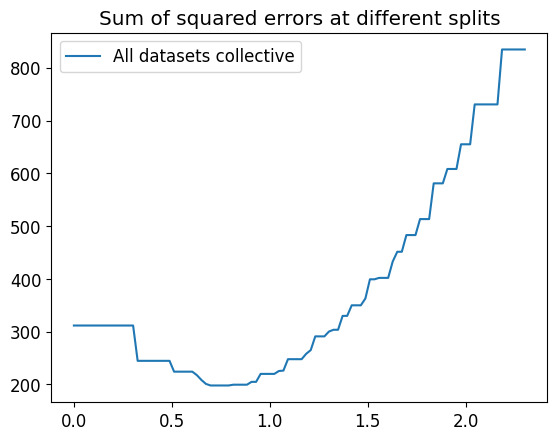

In [12]:
# Best universal split across datasets
split_method = 'best-universal-split'
all_entropy = torch.cat([D.entropy for D in Ds], dim=0)
split = best_split(all_entropy, "All datasets collective")
plt.legend()
plt.title('Sum of squared errors at different splits')
for D in Ds:
    D.b_entropy = binarize_entropy(D.entropy, split)
    print(f"Dummy accuracy for {D.name}: {max(torch.mean(D.b_entropy).item(), 1-torch.mean(D.b_entropy).item()):.4f}")

#### About trinarizing entropy: 

We can also leave out middle SE portion for better probing; we adopted this strategy for Llama2-70b long-form generation.


In [ ]:
def trinarize_entropy(entropy, thres1=0.639, thres2=1.478):
    """Trinarize entropy scores into 0's and 1's"""
    trinary_entropy = torch.full_like(entropy, -1, dtype=torch.float)
    trinary_entropy[entropy < thres1] = 0
    trinary_entropy[entropy > thres2] = 1
    return trinary_entropy

split_method = 'tri-universal-split'
for D in Ds:
    D.t_entropy = t_entropy = trinarize_entropy(D.entropy, split, split)
    D.t_slt_dataset = D.slt_dataset[:, t_entropy != -1, :]
    D.t_tbg_dataset = D.tbg_dataset[:, t_entropy != -1, :]
    D.t_entropy = D.t_entropy[t_entropy != -1]
    D.t_accuracies = D.accuracies[t_entropy != -1]
    print('current left samples:', len(D.t_entropy))

### Train linear probes to predict Binarized SE

In [13]:
# for D in Ds:
#     train_single_metric(D, 'tbg', 'b_entropy')
#     train_single_metric(D, 'slt', 'b_entropy')
for D in Ds:
    for position_label in POSITIONS.keys():
        train_single_metric(D, position_label, "b_entropy")

X_trains 33
(1440, 4096)
y_trains 33
Training on trivia-qa-TBG-b_entropy 1/33
Validation Accuracy: 0.6917, AUROC: 0.5000
Training Loss: 0.6194, Validation Loss: 0.6178
Test Loss: 0.6031, Test Accuracy: 0.7100, AUROC: 0.5000
Training on trivia-qa-TBG-b_entropy 2/33
Validation Accuracy: 0.6917, AUROC: 0.5438
Training Loss: 0.6003, Validation Loss: 0.6160
Test Loss: 0.5884, Test Accuracy: 0.7100, AUROC: 0.6257
Training on trivia-qa-TBG-b_entropy 3/33
Validation Accuracy: 0.6917, AUROC: 0.5356
Training Loss: 0.5912, Validation Loss: 0.6206
Test Loss: 0.5845, Test Accuracy: 0.7200, AUROC: 0.6184
Training on trivia-qa-TBG-b_entropy 4/33
Validation Accuracy: 0.6861, AUROC: 0.5802
Training Loss: 0.5692, Validation Loss: 0.6122
Test Loss: 0.5749, Test Accuracy: 0.7100, AUROC: 0.6418
Training on trivia-qa-TBG-b_entropy 5/33
Validation Accuracy: 0.6806, AUROC: 0.6053
Training Loss: 0.5494, Validation Loss: 0.6051
Test Loss: 0.5679, Test Accuracy: 0.7250, AUROC: 0.6582
Training on trivia-qa-TBG-b_

In [14]:
Ds_res = []
for path in ds_paths:
    Ds_res.append(Dataset(load_dataset(path, use_residual=True)))  # residuals

for i, D_res in enumerate(Ds_res):
    D_res.name = ds_names[i]
    D_res.path = ds_paths[i]
    D_res.b_entropy = Ds[i].b_entropy  # reuse same labels

for D_res in Ds_res:
    train_single_metric(D_res, "TBG", "b_entropy")
    train_single_metric(D_res, "Second-last", "b_entropy")

X_trains 33
(1440, 4096)
y_trains 33
Training on trivia-qa-TBG-b_entropy 1/33
Validation Accuracy: 0.6917, AUROC: 0.5000
Training Loss: 0.6194, Validation Loss: 0.6178
Test Loss: 0.6031, Test Accuracy: 0.7100, AUROC: 0.5000
Training on trivia-qa-TBG-b_entropy 2/33
Validation Accuracy: 0.6917, AUROC: 0.5437
Training Loss: 0.6003, Validation Loss: 0.6160
Test Loss: 0.5884, Test Accuracy: 0.7100, AUROC: 0.6257
Training on trivia-qa-TBG-b_entropy 3/33
Validation Accuracy: 0.6917, AUROC: 0.5368
Training Loss: 0.5961, Validation Loss: 0.6191
Test Loss: 0.5875, Test Accuracy: 0.7200, AUROC: 0.6036
Training on trivia-qa-TBG-b_entropy 4/33
Validation Accuracy: 0.6889, AUROC: 0.5894
Training Loss: 0.5743, Validation Loss: 0.6081
Test Loss: 0.5749, Test Accuracy: 0.7250, AUROC: 0.6453
Training on trivia-qa-TBG-b_entropy 5/33
Validation Accuracy: 0.6917, AUROC: 0.6085
Training Loss: 0.5620, Validation Loss: 0.6018
Test Loss: 0.5696, Test Accuracy: 0.7250, AUROC: 0.6705
Training on trivia-qa-TBG-b_

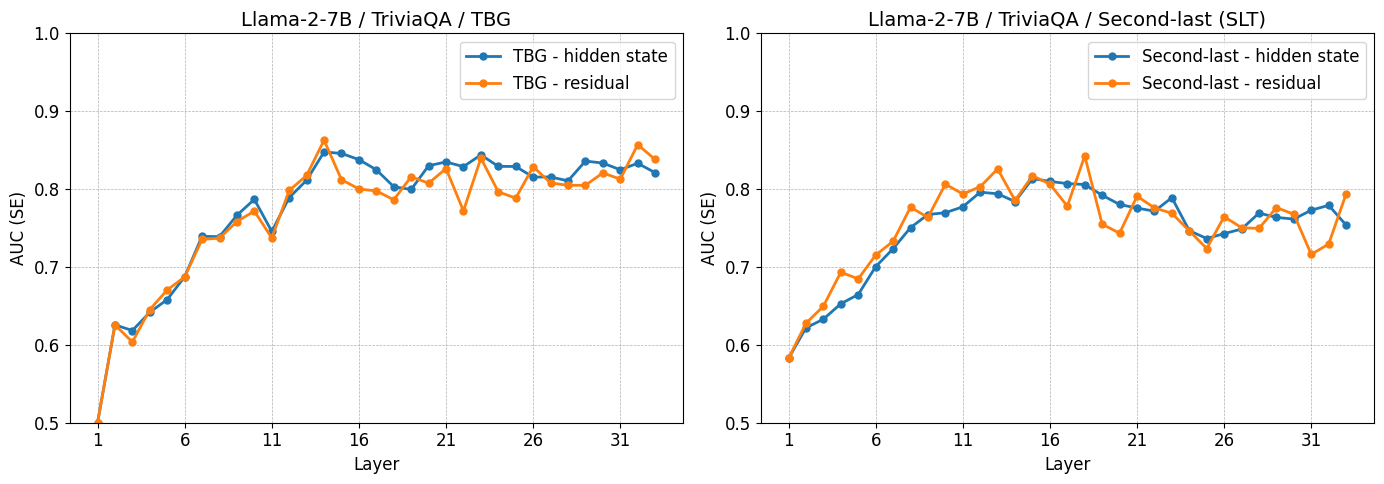

In [15]:
D = Ds[0]
D_res = Ds_res[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_metrics_ax(
    ax1,
    [auc(D.tbg_b_entropy_aucs), auc(D_res.tbg_b_entropy_aucs)],
    ["TBG - hidden state", "TBG - residual"],
    "Llama-2-7B / TriviaQA / TBG",
    prep_func=idf,
)
ax1.set_ylabel("AUC (SE)")
ax1.set_ylim(0.5, 1.0)

plot_metrics_ax(
    ax2,
    [auc(D.second_last_b_entropy_aucs), auc(D_res.second_last_b_entropy_aucs)],
    ["Second-last - hidden state", "Second-last - residual"],
    "Llama-2-7B / TriviaQA / Second-last (SLT)",
    prep_func=idf,
)
ax2.set_ylabel("AUC (SE)")
ax2.set_ylim(0.5, 1.0)

plt.tight_layout()
plt.show()

In [1]:
# D = Ds[0]  # TriviaQA

# fig, ax = plt.subplots(figsize=(6, 4.5))

# plot_metrics_ax(
#     ax,
#     [auc(D.tb_aucs), auc(D.sb_aucs)],
#     ["TBG", "SLT"],
#     "Llama-2-7B / TriviaQA / TBG vs SLT",
#     prep_func=idf
# )

# ax.set_ylabel("AUC (SE)")
# ax.set_xlabel("Layer")
# ax.set_ylim(0.5, 1.0)
# plt.tight_layout()
# plt.show()
D = Ds[0]

fig, ax = plt.subplots(figsize=(9,5))

plot_metrics_ax(
    ax,
    [
        auc(D.tbg_b_entropy_aucs),
        auc(D.first_b_entropy_aucs),
        auc(D.second_b_entropy_aucs),
        auc(D.third_b_entropy_aucs),
        # auc(D.fourth_b_entropy_aucs),
        # auc(D.fifth_b_entropy_aucs),
        # auc(D.fifth_last_b_entropy_aucs),
        # auc(D.fourth_last_b_entropy_aucs),
        auc(D.third_last_b_entropy_aucs),
        auc(D.second_last_b_entropy_aucs),
        auc(D.last_b_entropy_aucs),
    ],
    [
        "TBG",
        "First",
        "Second",
        "Third",
        # "Fourth",
        # "Fifth",
        # "Fifth-last",
        # "Fourth-last",
        "Third-last",
        "Second-last",
        "Last",
    ],
    "Llama-2-7B / TriviaQA / token-position comparison / residuals",
    prep_func=idf,
    legend_outside=True,
)

ax.set_ylabel("AUC (SE)")
ax.set_xlabel("Layer")
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

NameError: name 'Ds' is not defined

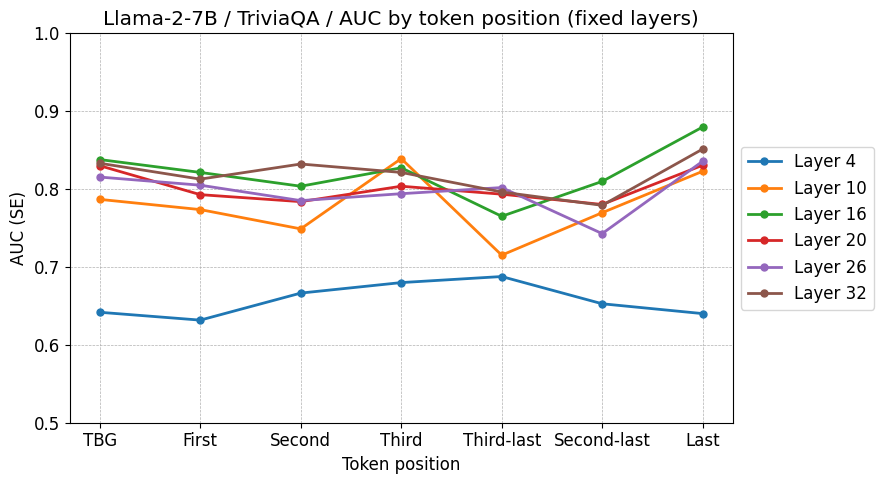

In [20]:
D = Ds[0]

# Fixed layers to compare (1-indexed display labels)
fixed_layers = [4, 10, 16, 20, 26, 32]

pos_labels      = ["TBG", "First", "Second", "Third", "Third-last", "Second-last", "Last"]
pos_attr_prefixes = ["tbg", "first", "second", "third", "third_last", "second_last", "last"]
x_ticks = range(len(pos_labels))

fig, ax = plt.subplots(figsize=(9, 5))

for layer in fixed_layers:
    layer_idx = layer - 1  # 1-indexed → 0-indexed
    values = [auc(getattr(D, f"{prefix}_b_entropy_aucs"))[layer_idx] for prefix in pos_attr_prefixes]
    ax.plot(x_ticks, values, marker='o', linestyle='-', linewidth=2, markersize=5, label=f"Layer {layer}")

ax.set_xticks(x_ticks)
ax.set_xticklabels(pos_labels)
ax.set_ylabel("AUC (SE)")
ax.set_xlabel("Token position")
ax.set_ylim(0.5, 1.0)
ax.set_title("Llama-2-7B / TriviaQA / AUC by token position (fixed layers)")
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
plt.tight_layout()
plt.show()

In [37]:
for k in D.__dict__.keys():
    print(k)

position_datasets
entropy
accuracies
name
path
other_ids
other_names
b_entropy
tbg_b_entropy_accs
tbg_b_entropy_aucs
tbg_b_entropy_models
first_b_entropy_accs
first_b_entropy_aucs
first_b_entropy_models
second_last_b_entropy_accs
second_last_b_entropy_aucs
second_last_b_entropy_models
last_b_entropy_accs
last_b_entropy_aucs
last_b_entropy_models


In [ ]:
#debug test added by aya
import pickle
import torch

with open("/data/mtk53658/semantic-entropy-probes/semantic_entropy_probes/wandb_runs/Llama2-7b/run-pt2esapp/validation_generations.pkl", "rb") as f:
    generations = pickle.load(f)

record = next(iter(generations.values()))
mla = record["most_likely_answer"]

print(mla.keys())

old_field_1 = mla["emb_last_tok_before_gen"]
old_field_2 = mla["emb_tok_before_eos"]

print("emb_last_tok_before_gen shape:", old_field_1.shape)
print("emb_tok_before_eos shape:", old_field_2.shape)

dict_keys(['response', 'token_log_likelihoods', 'embedding', 'accuracy', 'emb_last_tok_before_gen', 'emb_tok_before_eos'])
emb_last_tok_before_gen shape: torch.Size([33, 1, 4096])
emb_tok_before_eos shape: torch.Size([33, 1, 4096])


TypeError: 'Axes' object is not subscriptable

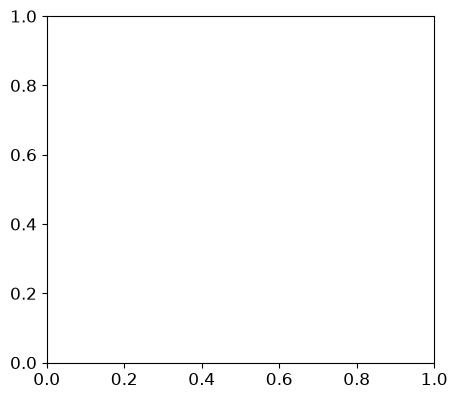

In [17]:
# plot se probe
fig, axs = plt.subplots(1, len(Ds), figsize=(5 * len(Ds), 4.5))
for i, D in enumerate(Ds):
    plot_metrics_ax(axs[i], [auc(D.tb_aucs), auc(D.sb_aucs)], ["SE Probe on TBG token", "SE Probe on SLT token"], 
                    f"AUROC on {D.name.upper()}", prep_func=idf)
plt.tight_layout()
save_fig(name="se_both_tok")
plt.show()

### Train linear probes to predict Accuracy

In [ ]:
for D in Ds:
    train_single_metric(D, 'tbg', 'accuracies')
    train_single_metric(D, 'slt', 'accuracies')

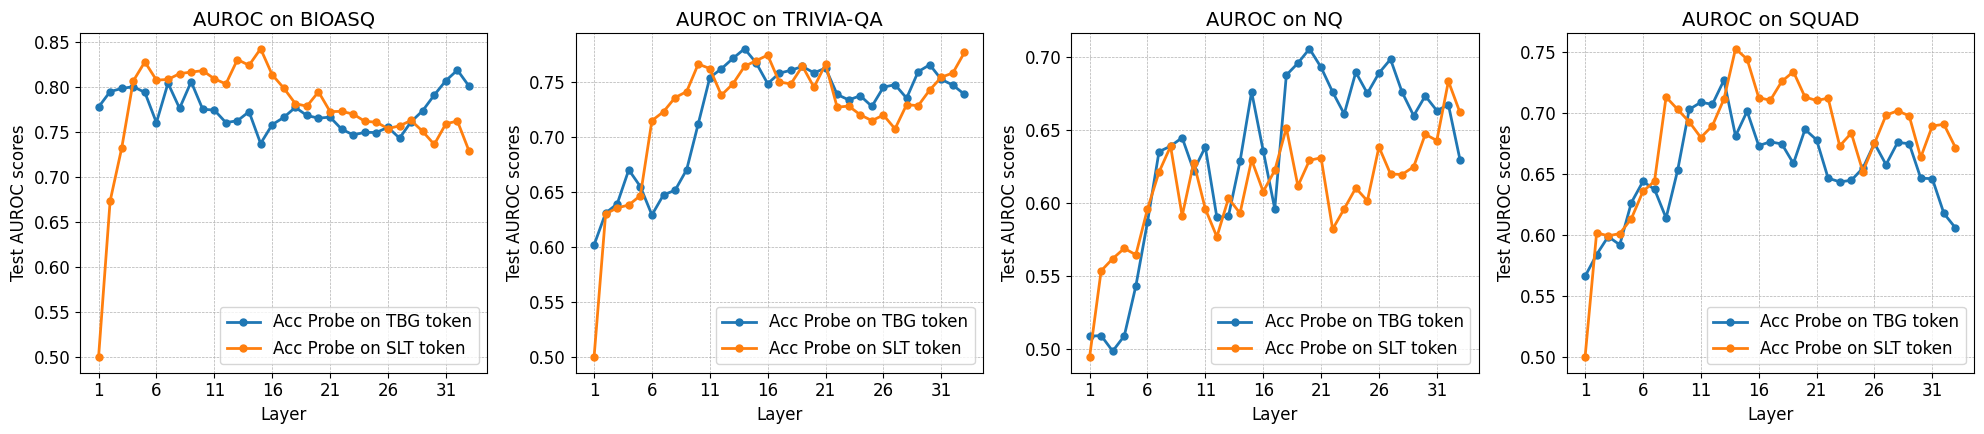

In [18]:
# plot acc probe
fig, axs = plt.subplots(1, len(Ds), figsize=(5 * len(Ds), 4.5))
for i, D in enumerate(Ds):
    plot_metrics_ax(axs[i], [auc(D.ta_aucs), auc(D.sa_aucs)], ["Acc Probe on TBG token", "Acc Probe on SLT token"], 
                    f"AUROC on {D.name.upper()}", prep_func=idf)
plt.tight_layout()
save_fig(name="acc_both_tok")
plt.show()

### Use linear probe trained on Binarized SE to predict Accuracy

We leverage trained probes on semantic entropy to predict model correctness on the same dataset.

Note that we need to predict the error rate (1 minus accuracy) using SEPs due to the nature of semantic uncertainty.

In [ ]:
for D in Ds:
    r_acc = 1 - D.accuracies
    
    # TBG
    _, _, X_tests, _, _, y_tests = create_Xs_and_ys(D.tbg_dataset, r_acc) 
    tab_accs = []
    tab_aucs = []
    
    for i, (X_test, y_test) in enumerate(zip(X_tests, y_tests)):
        print(f"Testing on {D.name}-TBG {i+1}/{len(X_tests)}")
        model = D.tb_models[i]
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test)
        tab_accs.append(test_acc)
        tab_aucs.append(test_auc)

    D.tab_accs = tab_accs
    D.tab_aucs = tab_aucs

    # SLT t
    _, _, X_tests, _, _, y_tests = create_Xs_and_ys(D.slt_dataset, r_acc)     
    sab_accs = []
    sab_aucs = []
    
    for i, (X_test, y_test) in enumerate(zip(X_tests, y_tests)):
        print(f"Testing on {D.name}-SLT {i+1}/{len(X_tests)}")
        model = D.sb_models[i]
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test)
        sab_accs.append(test_acc)
        sab_aucs.append(test_auc)

    D.sab_accs = sab_accs
    D.sab_aucs = sab_aucs

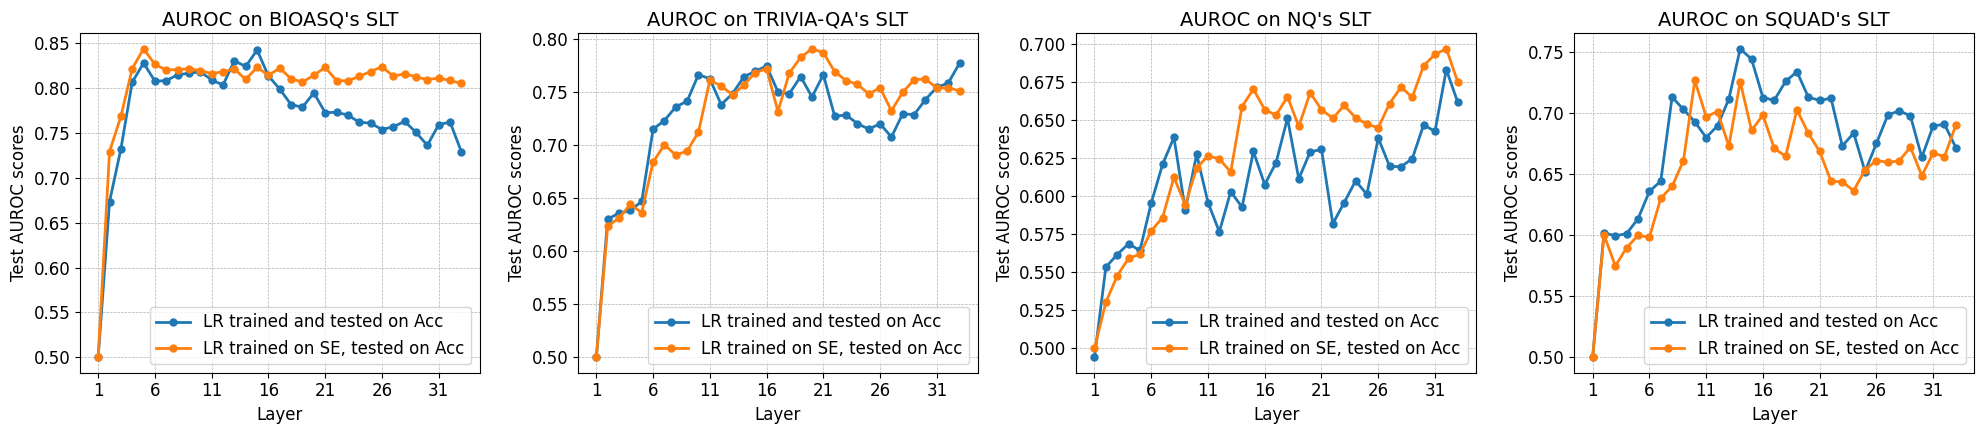

In [20]:
fig, axs = plt.subplots(1, len(Ds), figsize=(5 * len(Ds), 4.5))
for i, D in enumerate(Ds):
    plot_metrics_ax(axs[i], [D.sa_aucs, D.sab_aucs], ["LR trained and tested on Acc", "LR trained on SE, tested on Acc"], f"AUROC on {D.name.upper()}'s SLT")
plt.tight_layout()
save_fig(name="se_for_acc_slt")
plt.show()

In [21]:
# select best layer range (SLT)
def decide_layer_range(Ds, metric='entropy', limit=33): # NOTE: set upperbound to be number of layers+1; e.g. for llama2-70b, it is 81.
    """
    simple logic: use ID average test AUROCs across layers to determine 
    which consecutive range of layers did the best. Do separately
    for SEP and Acc. Pr.
    """
    assert hasattr(Ds[0], 'sab_aucs') and hasattr(Ds[0], 'sa_aucs'), 'previous cells need to be run'
    if 'entropy' in metric:
        aucs = [np.array(auc(D.sab_aucs)) for D in Ds]  # test metrics for ID SEPs
    else:
        aucs = [np.array(auc(D.sa_aucs)) for D in Ds]  # test metrics for ID APs
    best_mean = -np.inf
    best_range = []
    average = lambda a,b : np.mean([np.mean(ac[a:b]) for ac in aucs])

    for i in range(limit):
        for j in range(i+1, limit):
            if j - i < 5: # must be more than 5 layers
                continue
            if average(i, j) > best_mean:
                best_mean = average(i, j)
                best_range = [i, j]

    return best_mean, best_range

emean, (e1, e2) = decide_layer_range(Ds, 'entropy')
amean, (a1, a2) = decide_layer_range(Ds, 'acc')
for D in Ds:
    D.sep_layer_range = (e1, e2)
    D.ap_layer_range = (a1, a2)
print(emean, (e1, e2), amean, (a1, a2))

0.7328738142300604 (13, 21) 0.7306817842612249 (13, 18)


In [22]:
# BOOTSTRAP: select [xx-xx] layers for bootstrapping
def concat_Xs_and_ys(layer_range, X_trains, X_vals, X_tests, y_trains, y_vals, y_tests, 
                     no_val=False, test_only=False):
    """
    Concatenate @params{layer_range} hidden state layers on train/val/test sets.

    no_val: no validation (training set only).
    test_only: no train/validation set (test set only).
    """
    if not no_val:
        X_val_cc = np.concatenate(np.array(X_vals)[layer_range], axis=1)
        y_val_cc = y_vals[layer_range[0]]
    else:
        X_val_cc = y_val_cc = None

    if not test_only:
        X_train_cc = np.concatenate(np.array(X_trains)[layer_range], axis=1)
        y_train_cc = y_trains[layer_range[0]]
    else:
        X_train_cc = y_train_cc = None
    
    X_test_cc = np.concatenate(np.array(X_tests)[layer_range], axis=1)
    y_test_cc = y_tests[layer_range[0]]
    
    return X_train_cc, X_val_cc, X_test_cc, y_train_cc, y_val_cc, y_test_cc

def train_concat_SE(D, layer_range):
    """train model on single dataset SE with concatenated layers"""
    for token_type in ['slt']: # optionally, ['slt', 'tbg']
        var_name = token_type[0]
        all_Xs_and_ys = create_Xs_and_ys(getattr(D, f'{token_type}_dataset'), D.b_entropy, test_only=True) # train on all data
        _, _, X_train_cc, _, _, y_train_cc = concat_Xs_and_ys(layer_range, *all_Xs_and_ys, no_val=True, test_only=True)
        model = LogisticRegression()
        model.fit(X_train_cc, y_train_cc)
        setattr(D, f'{var_name}_bmodel', model)

        print(f'{token_type.upper()} trained on {D.name} SE finished')
    
def train_concat_Acc(D, layer_range):
    """train model on single dataset Accuracy with concatenated layers"""
    for token_type in ['slt']: # optionally, ['slt', 'tbg']
        var_name = token_type[0]
        all_Xs_and_ys = create_Xs_and_ys(getattr(D, f'{token_type}_dataset'), D.accuracies, test_only=True) # train on all data
        _, _, X_train_cc, _, _, y_train_cc = concat_Xs_and_ys(layer_range, *all_Xs_and_ys, no_val=True, test_only=True)
        model = LogisticRegression()
        model.fit(X_train_cc, y_train_cc)
        setattr(D, f'{var_name}_amodel', model)

        print(f'{token_type.upper()} trained on {D.name} Acc finished')

def train_concat_SE_Acc_test_Acc(D, layer_ranges=[list(range(e1,e2)), list(range(a1,a2))]):
    """ID: train and test SEPs and Acc. Pr. on single dataset with concatenated layers"""
    for token_type in ['slt']: # optionally, ['slt', 'tbg']
        var_name = token_type[0]
        all_Xs_and_ys = create_Xs_and_ys(getattr(D, f'{token_type}_dataset'), D.b_entropy, no_val=True) 
        
        X_train_cc, _, _, y_train_cc, _, _ = concat_Xs_and_ys(layer_ranges[0], *all_Xs_and_ys, no_val=True)
        ab_accs = []
        ab_aucs = []
        model = LogisticRegression()
        model.fit(X_train_cc, y_train_cc)

        all_Xs_and_ys = create_Xs_and_ys(getattr(D, f'{token_type}_dataset'), D.accuracies) 
        _, _, X_test_cc, _, _, y_test_cc = concat_Xs_and_ys(layer_ranges[0], *all_Xs_and_ys) # fixed random seed ensures no data leakage
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test_cc, 1-y_test_cc) # SEP predicts error rate
        ab_accs.append(test_acc)
        ab_aucs.append(test_auc)
    
        setattr(D, f'i{var_name}b_accs', ab_accs)  # i means IDß
        setattr(D, f'i{var_name}b_aucs', ab_aucs)

        print(f'{D.name.upper()}-{token_type.upper()} trainied on SE and tested on Acc finished')
        aa_accs = []
        aa_aucs = []
        X_train_cc, _, X_test_cc, y_train_cc, _, y_test_cc = concat_Xs_and_ys(layer_ranges[1], *all_Xs_and_ys, no_val=True)
        model = LogisticRegression()
        model.fit(X_train_cc, y_train_cc)
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test_cc, y_test_cc)
        aa_accs.append(test_acc)
        aa_aucs.append(test_auc)
    
        setattr(D, f'i{var_name}a_accs', aa_accs)
        setattr(D, f'i{var_name}a_aucs', aa_aucs)
        print(f'{D.name.upper()}-{token_type.upper()} trainied on Acc and tested on Acc finished')

In [ ]:
# ID: train SEPs and Acc. Pr. and test them on Acc. from the same dataset
# import warnings # uncomment to disable convergence warnings
# warnings.filterwarnings('ignore')

for D in Ds:
    train_concat_SE_Acc_test_Acc(D)

In [ ]:
# OOD: save model trained on individual datasets for OOD tests
for D in Ds:
    train_concat_SE(D, layer_range=list(range(e1,e2)))
    train_concat_Acc(D, layer_range=list(range(a1,a2)))
# outputs cleared for space concern

## Test probes trained with one dataset on others

We generalize SE and Acc. probes to Out-of-Distribution settings (OOD).

In [25]:
# Train on one's Acc/SE and test on others' Acc
def test_one_on_n(D, token_type='slt', 
                  layer_range1=list(range(e1,e2)), 
                  layer_range2=list(range(a1,a2))):
    var_name = token_type[0]
    other_ids = D.other_ids
    other_names = D.other_names
    metric = 'accuracies'
    a_model = getattr(D, f'{var_name}_amodel')  # Acc. Probe
    b_model = getattr(D, f'{var_name}_bmodel')  # SE Probe

    print(f"Using probes trained on datasets {D.name.upper()}'s {token_type.upper()}-SE/Acc to predict {other_names}'s {token_type.upper()}-Acc")

    oa_accs = {}
    oa_aucs = {}
    ob_accs = {}
    ob_aucs = {}
    
    for id_ in D.other_ids:
        D_id = Ds[id_]
        print(f"Testing on {D_id.name.upper()}'s {token_type.upper()}-{metric.upper()}")
        if metric == 'accuracies':
            y_metric = 1 - getattr(D_id, metric)  # error rate
        else:
            y_metric = getattr(D_id, metric)
        
        ida_accs = []
        ida_aucs = []
        idb_accs = []
        idb_aucs = []

        # create test sets with accuracy labels
        all_Xs_and_ys = create_Xs_and_ys(getattr(D_id, f'{token_type}_dataset'), y_metric, test_only=True)

        # test on Acc. Probes
        _, _, X_test_cc, _, _, y_test_cc = concat_Xs_and_ys(layer_range2, *all_Xs_and_ys, no_val=True, test_only=True)
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(a_model, X_test_cc, 1-y_test_cc, bootstrap=True)
        ida_accs.append(test_acc)
        ida_aucs.append(test_auc)
        
        # test on SE Probes
        _, _, X_test_cc, _, _, y_test_cc = concat_Xs_and_ys(layer_range1, *all_Xs_and_ys, no_val=True, test_only=True)
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(b_model, X_test_cc, y_test_cc, bootstrap=True)
        idb_accs.append(test_acc)
        idb_aucs.append(test_auc)

        oa_accs[D_id.name] = ida_accs
        oa_aucs[D_id.name] = ida_aucs
        ob_accs[D_id.name] = idb_accs
        ob_aucs[D_id.name] = idb_aucs

    setattr(D, 'osa_accs', oa_accs) # o means OOD
    setattr(D, 'osa_aucs', oa_aucs)
    setattr(D, 'osb_accs', ob_accs)
    setattr(D, 'osb_aucs', ob_aucs)

    print(f"Using probes trained on dataset {D.name.upper()} testing complete.")

In [26]:
for D in Ds:
    test_one_on_n(D, 'slt')

Using probes trained on datasets BIOASQ's SLT-SE/Acc to predict ['trivia-qa', 'nq', 'squad']'s SLT-Acc
Testing on TRIVIA-QA's SLT-ACCURACIES
Test Loss: 1.6577, Test Accuracy: 0.5810, AUROC: 0.6128
Test Loss: 1.9539, Test Accuracy: 0.6500, AUROC: 0.6925
Testing on NQ's SLT-ACCURACIES
Test Loss: 1.7527, Test Accuracy: 0.5535, AUROC: 0.5728
Test Loss: 2.6667, Test Accuracy: 0.4810, AUROC: 0.6586
Testing on SQUAD's SLT-ACCURACIES
Test Loss: 1.2898, Test Accuracy: 0.6640, AUROC: 0.6146
Test Loss: 2.2163, Test Accuracy: 0.5065, AUROC: 0.6435
Using probes trained on dataset BIOASQ testing complete.
Using probes trained on datasets TRIVIA-QA's SLT-SE/Acc to predict ['bioasq', 'nq', 'squad']'s SLT-Acc
Testing on BIOASQ's SLT-ACCURACIES
Test Loss: 2.0895, Test Accuracy: 0.5890, AUROC: 0.5282
Test Loss: 1.7397, Test Accuracy: 0.5645, AUROC: 0.6155
Testing on NQ's SLT-ACCURACIES
Test Loss: 1.4719, Test Accuracy: 0.6265, AUROC: 0.6375
Test Loss: 2.8541, Test Accuracy: 0.5380, AUROC: 0.6583
Testing 

In [28]:
# compute the OOD average: mean([train on B-> test on A, train on C -> test on A, train on D-> test on A])
b_performances = defaultdict(list)
a_performances = defaultdict(list)
win_rate = []
for D in Ds:
    for name in D.other_names:
        b_performances[name].append(auc(D.osb_aucs[name]))
        a_performances[name].append(auc(D.osa_aucs[name]))
        if auc(D.osb_aucs[name]) > auc(D.osa_aucs[name]):
            win_rate.append(1)
        else:
            win_rate.append(0)

print(f"winning rate: {np.mean(win_rate)*100:.2f}%")

for D in Ds:
    D.sep_ood_avg = np.mean(b_performances[D.name])
    D.ap_ood_avg = np.mean(a_performances[D.name])
    print(f"Average performance on {D.name}: SE Probe - {D.sep_ood_avg}, Acc Probe - {D.ap_ood_avg}")

winning rate: 100.00%
Average performance on bioasq: SE Probe - 0.6948333784271284, Acc Probe - 0.5700345390286797
Average performance on trivia-qa: SE Probe - 0.675374793177231, Acc Probe - 0.6298670270363921
Average performance on nq: SE Probe - 0.6563975736850676, Acc Probe - 0.6100365372089236
Average performance on squad: SE Probe - 0.6368174572302435, Acc Probe - 0.5975483802655447


## Baselines and Performance Plots

Optional section for baselines and plotting barplots like in the paper.

Baselines include log-likelihoods, p-true, naive (predictive) entropy, and semantic entropy predicted model correctness, in the form of AUROC score.

In [31]:
# log likelihood baseline (a bit slow due to file loading)
for D in Ds:
    with open(f"{D.path}/{run_files['VAL_GEN']}", 'rb') as file:
        gens = pickle.load(file)
    liks = torch.tensor([np.mean(record['most_likely_answer']['token_log_likelihoods']) for record in gens.values()])
    accs = torch.tensor([record['most_likely_answer']['accuracy'] for record in gens.values()])
    probs = np.exp(liks)
    D.loglik = bootstrap_func(accs, probs, auroc)
    print(f"{D.name} log-lik: {D.loglik['mean']:.4f}")

/scratch/ms23jh/conda_envs/llm/lib/python3.11/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))


bioasq log-lik: 0.5940


/scratch/ms23jh/conda_envs/llm/lib/python3.11/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))


trivia-qa log-lik: 0.5586


/scratch/ms23jh/conda_envs/llm/lib/python3.11/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))


nq log-lik: 0.5716


/scratch/ms23jh/conda_envs/llm/lib/python3.11/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))


squad log-lik: 0.5650


In [33]:
# p_true and naive entropy baselines from uncertainty_measures and wandb_summary 
# You should've enabled `--compute_p_true` in generation runs.
for i, path in enumerate(ds_paths):
    os.chdir(path)

    # no need to run again once collected
    if hasattr(Ds[i], 'p_false_fixed') and hasattr(Ds[i], 'baseline_se'):
        continue

    with open(run_files['UNC_MEA'], 'rb') as file:
        measures = pickle.load(file)

    p_false_fixed_tuple = (measures['validation_is_false'], measures['uncertainty_measures']['p_false_fixed'])

    metric_i = auroc(*p_false_fixed_tuple)
    p_false_fixed_dict = {}
    p_false_fixed_dict['mean'] = metric_i
    p_false_fixed_dict['bootstrap'] = compatible_bootstrap(
        auroc, rng)(*p_false_fixed_tuple)  # a bit slow to run

    Ds[i].p_false_fixed = p_false_fixed_dict

    with open(run_files['WAN_SUM'], 'rb') as file:  # auto-collected with analyze_run.py
        boots = json.load(file)

    Ds[i].baseline_se = boots['uncertainty']['cluster_assignment_entropy']['AUROC']
    Ds[i].baseline_re = boots['uncertainty']['regular_entropy']['AUROC']

    print(f"Baselines for {Ds[i].name} computed.")

Baselines for bioasq computed.
Baselines for trivia-qa computed.
Baselines for nq computed.
Baselines for squad computed.


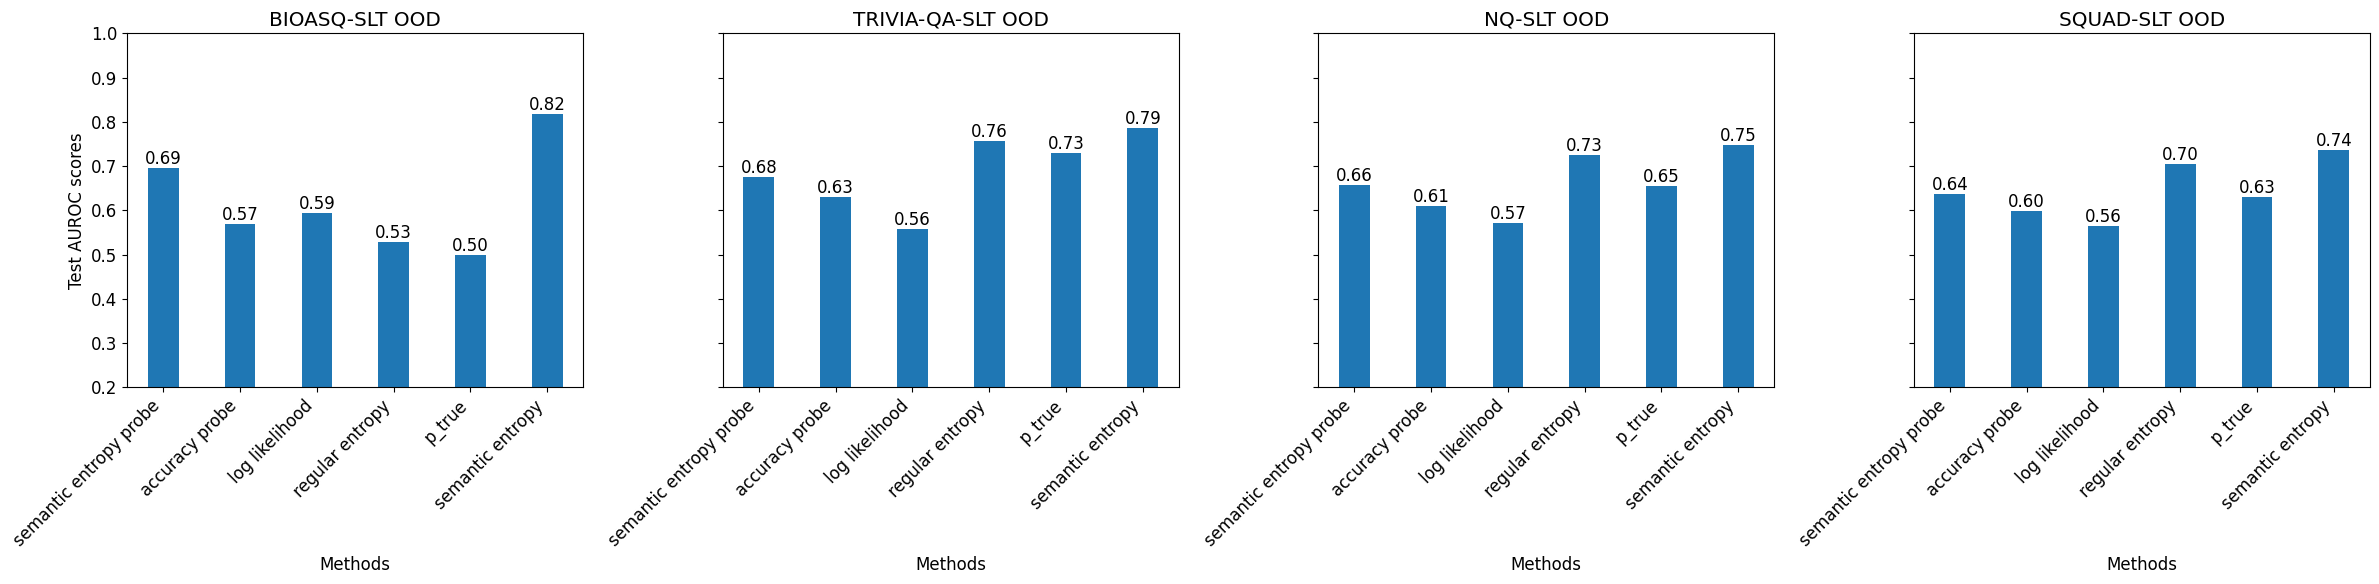

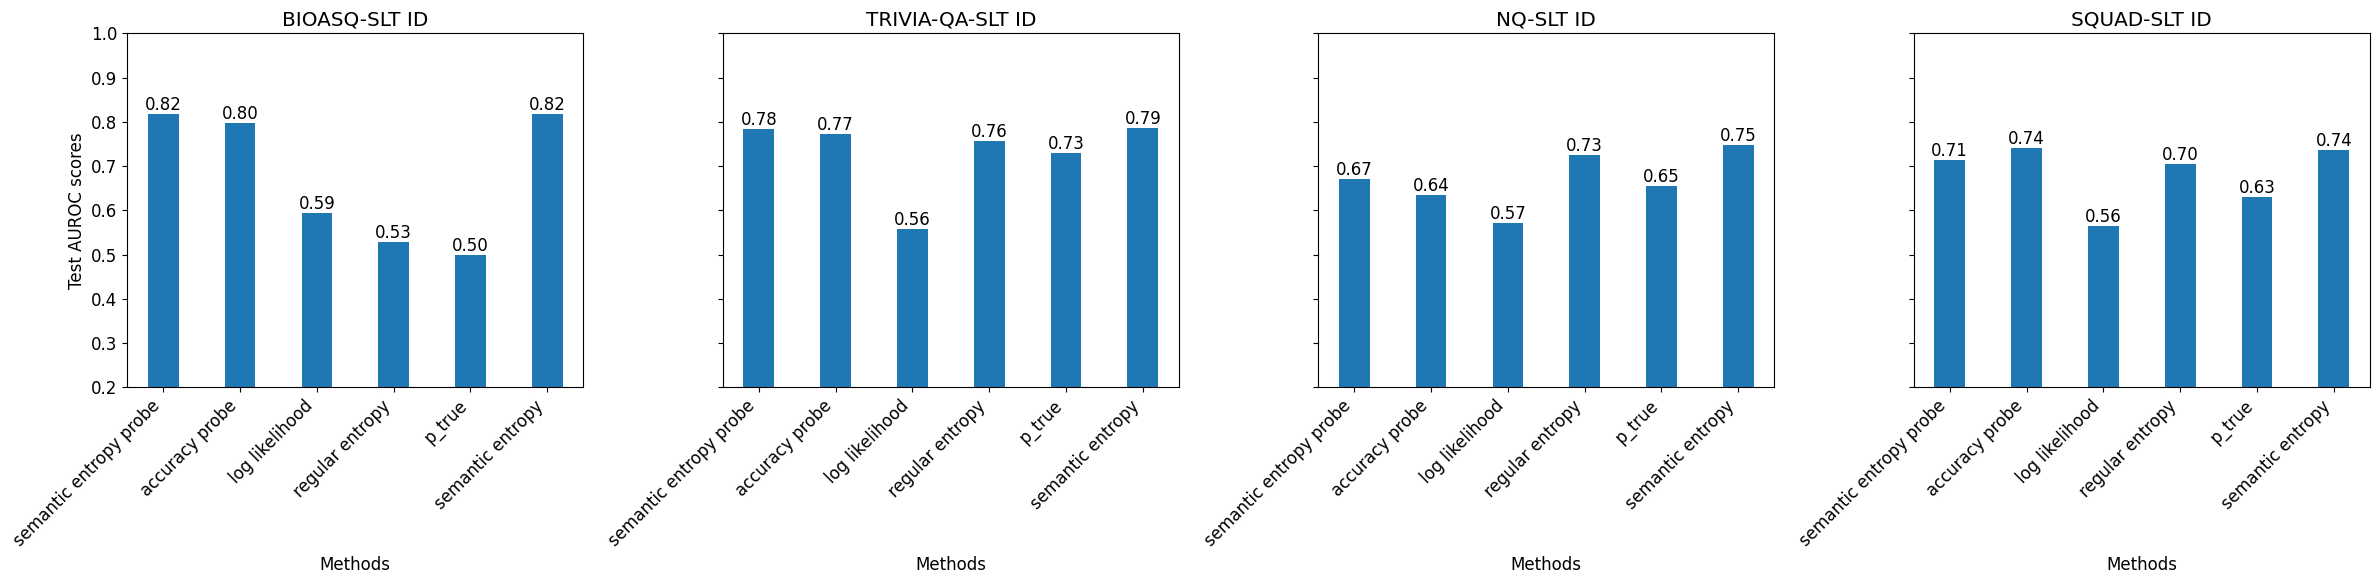

In [34]:
# plot performances
def plot_performance_barplots(Ds, types=['ood', 'id']):
    n = len(Ds)
    for type_ in types:
        fig, axes = plt.subplots(1, n, figsize=(n * 6, 6), sharey=True)
        
        for i, (D, ax) in enumerate(zip(Ds, axes)):
            x_labels = ['semantic entropy probe', 'accuracy probe', 'log likelihood', 'regular entropy', 'p_true', 'semantic entropy']

            if type_ == 'id':
                values = [D.isb_aucs[0]['mean'], D.isa_aucs[0]['mean'], D.loglik['mean'], D.baseline_re['mean'], 
                         0.5 if D.name == 'bioasq' else D.p_false_fixed['mean'], D.baseline_se['mean']]
            elif type_ == 'ood':
                values = [D.sep_ood_avg, D.ap_ood_avg, D.loglik['mean'], D.baseline_re['mean'], 
                          0.5 if D.name == 'bioasq' else D.p_false_fixed['mean'], D.baseline_se['mean']]
            else:
                return
                
            bars = ax.bar(x_labels, values, width=0.4, capsize=5) 
            ax.set_xlabel('Methods')
            if i == 0:  
                ax.set_ylabel('Test AUROC scores')
            ax.set_ylim(0.2, 1.0)
            ax.set_title(f"{D.name.upper()}-SLT {type_.upper()}")
            ax.set_xticklabels(x_labels, rotation=45, ha='right')
        
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2f}', ha='center', va='bottom')
        
        plt.tight_layout()  
        save_fig(f'{type_}_performance_barplot')
        plt.show()

plot_performance_barplots(Ds)

## Save trained probes for inference


In [35]:
# save models to pickle for inference
Ds_save = ()
to_save_attrs = ['s_amodel', 's_bmodel', 't_amodel', 't_bmodel', 'sep_layer_range', 'ap_layer_range', 'name']

for D in Ds:
    D_save = {key: value for key, value in vars(D).items() if key in to_save_attrs}
    Ds_save += (D_save,)

path = f"{notebook_path}/models"
full_path = os.path.expanduser(path)
os.makedirs(full_path, exist_ok=True)

with open(f'{full_path}/{model_name}_inference.pkl', 'wb') as f:
    pickle.dump(Ds_save, f)